In [16]:
import numpy as np
import cv2 as cv
 
img = cv.imread('cat.jpg')

In [17]:
px = img[100,100]
print(px)
 
# accessing only blue pixel
blue = img[100,100,0]
print(blue)

[ 58 101 122]
58


In [18]:
img[100,100] = [255,255,255]
print(img[100,100])

[255 255 255]


In [19]:
cv.imshow("Display window", img)
k = cv.waitKey(0)

In [20]:
# accessing RED value
#img.item(10,10,2)
px = img[10, 10, 2]
print(px)

# modifying RED value
img[10, 10, 2] = 255

72


In [21]:
cv.imshow("Display window", img)
k = cv.waitKey(0)

In [22]:
img.shape

(259, 194, 3)

In [23]:
img.size

150738

In [24]:
img.dtype

dtype('uint8')

In [35]:
face = img[60:120, 30:120]
img[0:60, 0:90] = face

In [36]:
cv.imshow("Display window", img)
k = cv.waitKey(0)

In [27]:
b,g,r = cv.split(img)
img = cv.merge((b,g,r))

In [34]:
b

array([[ 95, 100, 109, ...,  28,  28,  28],
       [ 94, 100, 111, ...,  26,  29,  29],
       [ 94,  99, 112, ...,  27,  29,  27],
       ...,
       [138,  87,  55, ..., 221, 227, 224],
       [ 58,  46,  41, ..., 222, 229, 223],
       [166, 181, 172, ..., 222, 227, 221]], shape=(259, 194), dtype=uint8)

In [28]:
b = img[:,:,0]
img[:,:,2] = 0

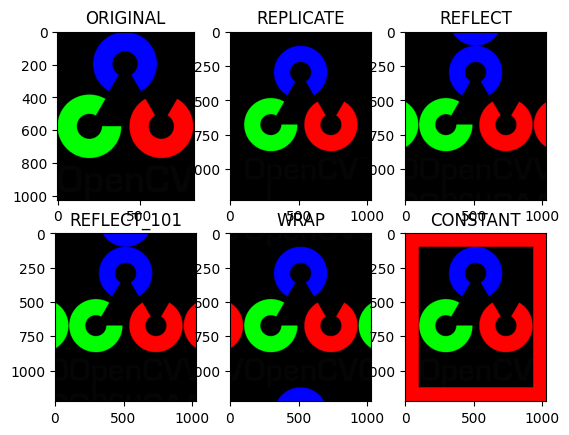

In [33]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
 
BLUE = [255,0,0]
 
img1 = cv.imread('opencv_logo.png')
 
replicate = cv.copyMakeBorder(img1,100,100,100,100,cv.BORDER_REPLICATE)
reflect = cv.copyMakeBorder(img1,100,100,100,100,cv.BORDER_REFLECT)
reflect101 = cv.copyMakeBorder(img1,100,100,100,100,cv.BORDER_REFLECT_101)
wrap = cv.copyMakeBorder(img1,100,100,100,100,cv.BORDER_WRAP)
constant= cv.copyMakeBorder(img1,100,100,100,100,cv.BORDER_CONSTANT,value=BLUE)
 
plt.subplot(231),plt.imshow(img1,'gray'),plt.title('ORIGINAL')
plt.subplot(232),plt.imshow(replicate,'gray'),plt.title('REPLICATE')
plt.subplot(233),plt.imshow(reflect,'gray'),plt.title('REFLECT')
plt.subplot(234),plt.imshow(reflect101,'gray'),plt.title('REFLECT_101')
plt.subplot(235),plt.imshow(wrap,'gray'),plt.title('WRAP')
plt.subplot(236),plt.imshow(constant,'gray'),plt.title('CONSTANT')
 
plt.show()

# second

In [87]:
x = np.uint8([250])
y = np.uint8([10])
 
print(cv.add(x,y)) # 250+10 = 260 => 255
print(x+y)

[[260.]
 [  0.]
 [  0.]
 [  0.]]
[4]


In [14]:
img1 = cv.imread('test.jpg')
img2 = cv.imread('opencv_logo.png')
assert img1 is not None, "file could not be read, check with os.path.exists()"
assert img2 is not None, "file could not be read, check with os.path.exists()"
 
dst = cv.addWeighted(img1,0.7,img2,0.3,0)
 
cv.imshow('dst',dst)
cv.waitKey(0)
cv.destroyAllWindows()

In [96]:
img1.shape

(1024, 831, 3)

In [15]:
# Load two images
img1 = cv.imread('messi5.jpg')
img2 = cv.imread('test.png')
 
# I want to put logo on top-left corner, So I create a ROI
rows,cols,channels = img2.shape
roi = img1[0:rows, 0:cols]
 
# Now create a mask of logo and create its inverse mask also
img2gray = cv.cvtColor(img2,cv.COLOR_BGR2GRAY)

cv.imshow("Display window", img2gray)
k = cv.waitKey(0)

ret, mask = cv.threshold(img2gray, 10, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)
# Now black-out the area of logo in ROI
img1_bg = cv.bitwise_and(roi,roi,mask = mask_inv)
 
# Take only region of logo from logo image.
img2_fg = cv.bitwise_and(img2,img2,mask = mask)
 
# Put logo in ROI and modify the main image
dst = cv.add(img1_bg,img2_fg)
img1[0:rows, 0:cols ] = dst
 
cv.imshow('res',img1)
cv.waitKey(0)
cv.destroyAllWindows()